# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Erick Lanford

**Dataset:** city_traffic_accidents

## Setup

Run this cell first to import all necessary libraries.

In [216]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

Predict severity level of traffic accidents, which represents the extent of injuries or damage resulting from the accident. This can help in understanding the impact of accidents and improving safety measures.

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

This prediction matters to city planners, traffic management authorities, and emergency response teams. Accurate predictions of traffic accident severity can help allocate resources more effectively, implement targeted safety measures, and improve overall public safety.

---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

Potential features that might help predict the target include road conditions, weather conditions, time of day, traffic volume, and driver behavior. These factors can influence the likelihood and severity of traffic accidents.

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [217]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/city_traffic_accidents.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 500,000 rows, 46 columns

Column names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [219]:
# cleaning - change all text to lower case

df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

In [220]:
# TODO: View the first 5 rows of your dataframe
#
# Hint: Use .head()

# YOUR CODE HERE:
df.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,a-1784167,source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,accident on six forks rd at i-440 cliff benson...,i-440 w,raleigh,wake,nc,27609,us,us/eastern,krdu,2019-10-29 12:51:00,69.0,69.0,73.0,29.77,10.0,e,5.0,0.00,mostly cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,day,day,day,day
1,a-862811,source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,accident on i-44 eastbound at union ave.,i-44 w,tulsa,tulsa,ok,74107,us,us/central,krvs,2021-10-13 06:29:00,76.0,76.0,85.0,29.01,10.0,s,8.0,0.01,light rain with thunder,False,False,False,False,False,False,False,False,False,False,False,False,False,night,night,night,day
2,a-4054572,source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,incident on i-20 wb near mm 126 road closed. t...,i-20 w,birmingham,jefferson,al,35234,us,us/central,kbhm,2022-08-14 14:53:00,89.0,89.0,46.0,29.33,10.0,var,3.0,0.00,fair,False,False,False,False,True,False,False,False,False,False,False,False,False,day,day,day,day
3,a-6147589,source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,slow traffic on i-10 w - san bernardino fwy w ...,i-10 w,ontario,san bernardino,ca,91764,us,us/pacific,kont,2021-06-25 18:53:00,84.0,84.0,32.0,28.84,10.0,w,9.0,0.00,fair,False,False,False,False,False,False,False,False,False,False,False,False,False,day,day,day,day
4,a-5025169,source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,stationary traffic on us-22 e from i-81 n to s...,ridgeview dr,harrisburg,dauphin,pa,17112,us,us/eastern,kcxy,2022-03-18 12:56:00,71.0,71.0,47.0,29.63,10.0,ene,5.0,0.00,fair,False,False,False,False,False,False,False,False,False,False,False,False,False,day,day,day,day


In [221]:
# TODO: View the last 5 rows of your dataframe
#
# Hint: Use .tail()

# YOUR CODE HERE:
df.tail(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
499995,a-2794184,source2,3,2018-04-30 14:49:59,2018-04-30 15:34:20,34.311428,-117.474609,NaN,NaN,0.000,slow lane blocked due to accident on i-15 sout...,barstow fwy s,san bernardino,san bernardino,ca,92407,us,us/pacific,ksbd,2018-04-30 14:50:00,64.4,NaN,42.0,29.94,5.0,calm,NaN,NaN,haze,False,False,False,False,False,False,False,False,False,False,False,False,False,day,day,day,day
499996,a-427475,source2,2,2017-05-01 08:43:09,2017-05-01 09:40:00,38.989349,-77.431366,NaN,NaN,0.010,accident on va-28 sully rd southbound at sterl...,s sterling blvd,sterling,loudoun,va,20166,us,us/eastern,kiad,2017-05-01 08:52:00,73.9,NaN,71.0,29.90,10.0,south,17.3,NaN,scattered clouds,False,False,False,False,True,False,False,False,False,False,False,False,False,day,day,day,day
499997,a-5929151,source1,2,2021-03-16 17:34:08,2021-03-16 19:36:12,45.075263,-93.331851,45.075413,-93.331001,0.043,accident from exit [33] to i-94 e.,brooklyn blvd,minneapolis,hennepin,mn,55429,us,us/central,kmic,2021-03-16 17:53:00,35.0,35.0,70.0,29.08,10.0,e,3.0,0.0,cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,day,day,day,day
499998,a-5889158,source1,2,2021-05-30 21:17:00,2021-05-30 22:01:30,34.043144,-118.272534,34.060493,-118.250860,1.725,stationary traffic on ca-110 n - harbor fwy n ...,ca-110 n,los angeles,los angeles,ca,90015,us,us/pacific,kcqt,2021-05-30 20:52:00,62.0,62.0,75.0,29.70,10.0,wsw,3.0,0.0,fair,False,False,False,False,False,False,False,False,False,False,False,False,False,night,night,night,day
499999,a-2442815,source2,2,2018-11-08 17:26:28,2018-11-08 17:56:03,44.136898,-92.416977,NaN,NaN,7.000,accident on us-63 between broadway and county ...,county road 21 ne,rochester,olmsted,mn,55906,us,us/central,k9mn,2018-11-08 17:35:00,27.1,20.7,70.0,30.30,10.0,west,5.8,NaN,overcast,False,False,False,False,False,False,False,False,False,True,False,False,False,night,night,day,day


### 2.2 Data Types and Info

In [ ]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
# Hint: Use .info()

# YOUR CODE HERE:
df.info()


In [ ]:
# TODO: Get summary statistics for numerical columns
#
# Hint: Use .describe()

# YOUR CODE HERE:
df.describe()


In [ ]:
# TODO: Get summary statistics for categorical columns
#
# Hint: Use .describe(include='object')

# YOUR CODE HERE:
df.describe(include='object')

### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
- Where did this data come from? (Kaggle link, source)
- What does each row represent?
- How many features do you have?
- What types of features do you have? (numerical, categorical)

**Your description:**

We get the data from the Maryland Pilots database. 
Each row represents a vessel transit event piloted by Maryland pilots.
The dataset contains 12 features.
The features include both numerical (e.g., DurationHours, Draught, DraftNumeric) and categorical (e.g., VesselType, CargoType) data types.

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [222]:
# Define your target variable
TARGET = 'Severity'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: Severity

Basic Statistics:
count    500000.000000
mean          2.212386
std           0.487531
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: Severity, dtype: float64


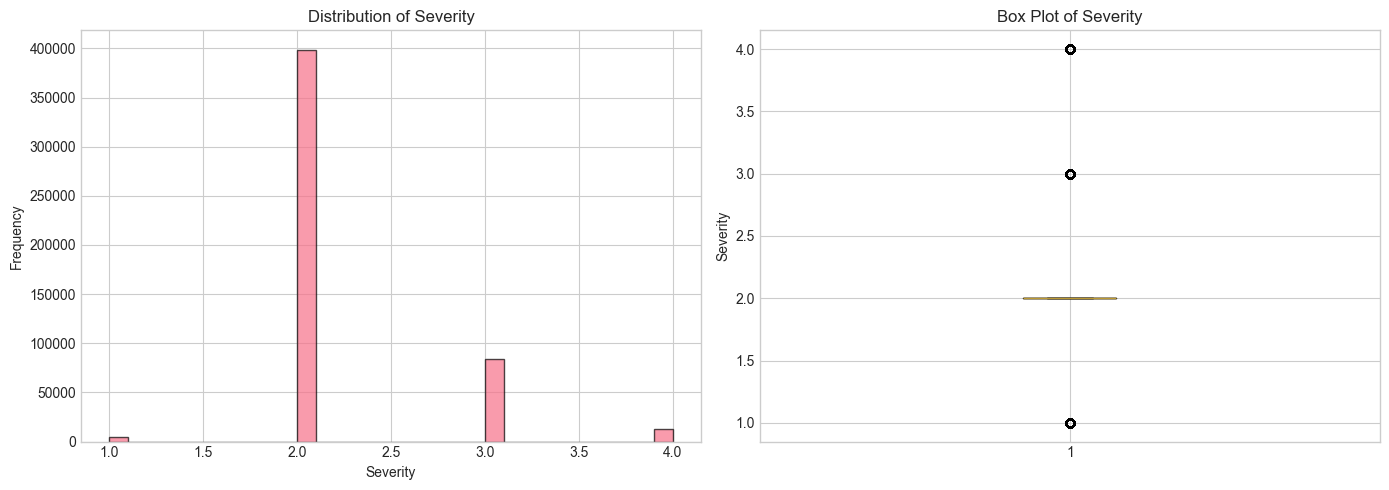


Skewness: 1.81
→ Target is highly skewed. Consider log transform in feature engineering.


In [204]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [ ]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
duplicate_rows = df.duplicated().sum()
percentage_duplicates = (duplicate_rows / len(df)) * 100
print(f"Duplicate rows: {duplicate_rows:,} ({percentage_duplicates:.2f}%)")

In [ ]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)


print("Columns that have missing values:")
print(missing_df)


In [ ]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**
- Is your target variable normally distributed or skewed?
- Are there any obvious outliers in the target?
- How much missing data do you have to deal with?
- Are there any duplicate rows?
- Any surprises or interesting findings?

**Your observations:**

Trip duration its skewed, but not normally distributed. Most of the values are close to the 400-800 min range.
There are some outliers, especially above ~1200 minutes.
There are small amounts of missing data in the "Propulsion" column (~0.5%) and also almost none duplicate rows (<0.1%).
An interesting finding is that trip duration median is around 600 minutes, which may indicate that most trips are relatively short, still more than 8 hours.


---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [205]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

# YOUR CODE HERE:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# numerical_categorical_cols = ['VesselTypeREF', 'StartLocationREF', 'StartBerthREF', 'EndLocationREF', 'EndBerthREF', 'MConcernREF']

# # Remove numerical_categorical_cols from numerical columns
# numerical_cols = [col for col in numerical_cols if col not in numerical_categorical_cols]

numerical_cols.remove(TARGET)
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")


Numerical features (12): ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']


In [ ]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [ ]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

# YOUR CODE HERE:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# add numerical_categorical_cols to categorical_cols
# categorical_cols += numerical_categorical_cols

print(f"Categorical columns: ({len(categorical_cols)}): {categorical_cols}")

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Top 10 value counts:\n{df[col].value_counts().head(10)}")

In [ ]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

In [ ]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 12]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

### 4.4 Correlation Analysis

In [ ]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:
#remove TARGET column

target_correlations = correlation_matrix[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)

In [ ]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

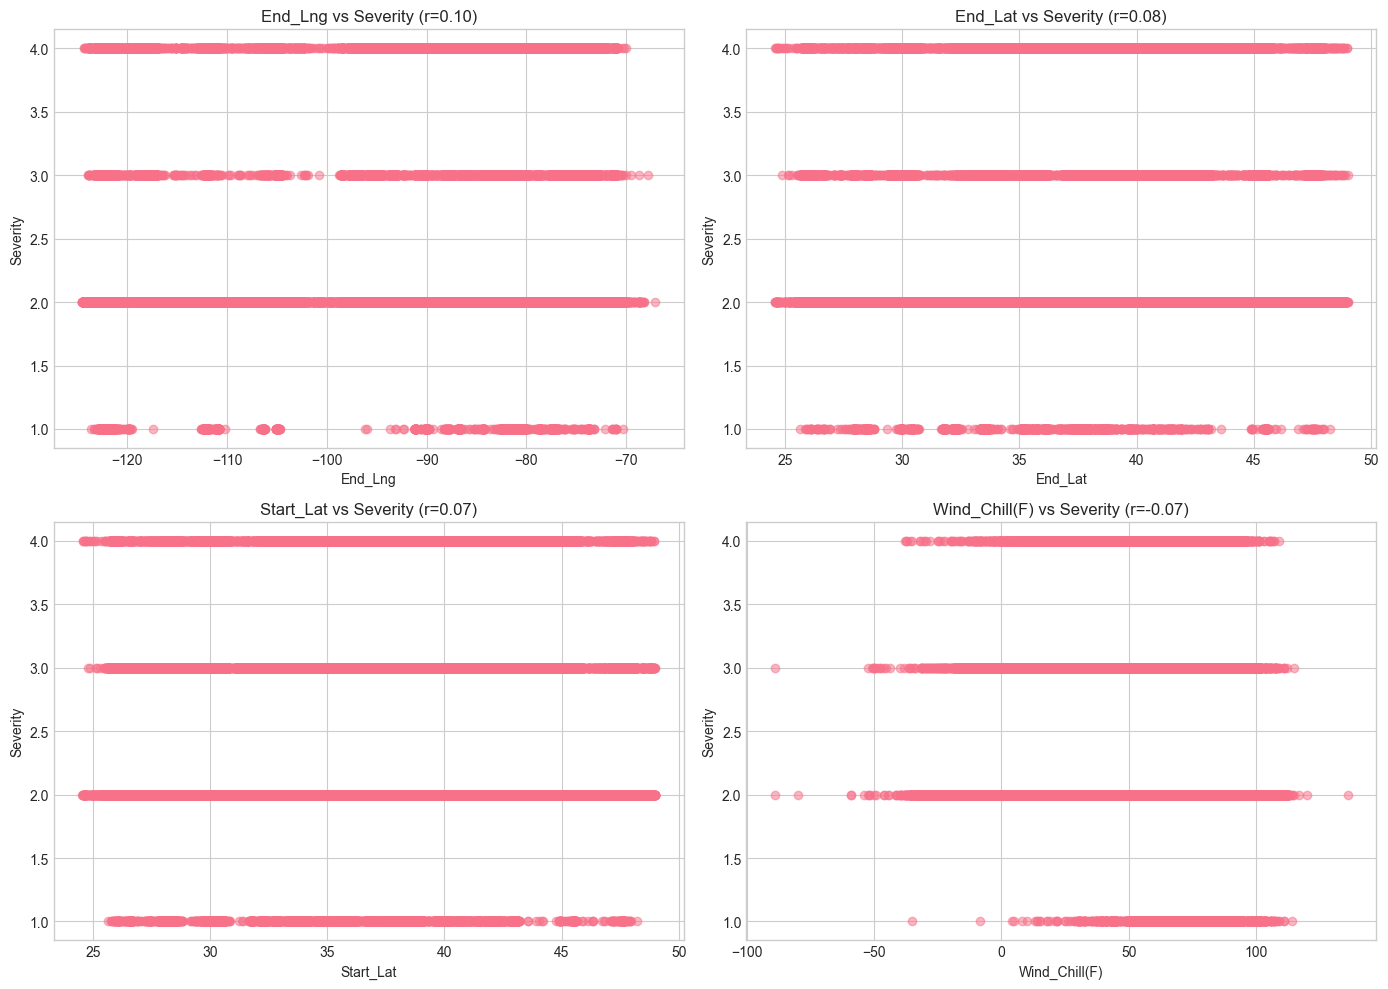

In [223]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

In [ ]:
# import re

# # Function to sanitize column names
# def safe_col(s):
#     return re.sub(r"[^0-9a-zA-Z_]+", "_", str(s)).strip("_")

In [ ]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!
# Adding Noaa (National Oceanic and Atmospheric Administration) data

# df_noaa_water_levels = pd.read_csv('../data/raw/noaa_water_levels_2024.csv', parse_dates=['t'])
# df_noaa_currents = pd.read_csv('../data/raw/noaa_currents_2024.csv', parse_dates=['t'])

# # create a copy of the original data
# df_with_noaa = df.copy()

# # 
# df_with_noaa["StartDateUTC"] = pd.to_datetime(df_with_noaa["StartDate"], utc=True)
# df_with_noaa = df_with_noaa.sort_values("StartDateUTC")


In [ ]:

# populate water levels
# for station in df_noaa_water_levels["Station"].unique():
#     df_station = df_noaa_water_levels[df_noaa_water_levels["Station"] == station].copy()
#     df_station["t"] = pd.to_datetime(df_station["t"], utc=True)
#     df_station = df_station.sort_values("t")

#     col = f"WL_{safe_col(station)}"
#     tmp = pd.merge_asof(
#         df_with_noaa[["StartDateUTC"]],
#         df_station[["t","v", "s", "f"]],
#         left_on="StartDateUTC",
#         right_on="t",
#         direction="nearest",
#         tolerance=pd.Timedelta("30min"),
#     ).rename(columns={"v": col, "s": f"{col}_speed", "f": f"{col}_flag"})

#     df_with_noaa[col] = tmp[col].values
#     df_with_noaa[f"{col}_speed"] = tmp[f"{col}_speed"].values
#     df_with_noaa[f"{col}_flag"] = tmp[f"{col}_flag"].values


In [ ]:
# # count nulls in water level columns
# wl_cols = [col for col in df_with_noaa.columns if col.startswith("WL_")]
# print("Null counts in water level columns:")

# for col in wl_cols:
#     null_count = df_with_noaa[col].isnull().sum()
#     print(f"{col}: {null_count} nulls")

In [ ]:
# # populate currents
# for station in df_noaa_currents["Station"].unique():
    
#     # skip Henrys as the data is unreliable
#     if station == "Cape Henry LB 2CH":
#         continue
    
#     df_station = df_noaa_currents[df_noaa_currents["Station"] == station].copy()
#     df_station["t"] = pd.to_datetime(df_station["t"], utc=True)
#     df_station = df_station.sort_values("t")

#     col = f"CUR_{safe_col(station)}"
#     tmp = pd.merge_asof(
#         df_with_noaa[["StartDateUTC"]],
#         df_station[["t","s", "d", "b"]],
#         left_on="StartDateUTC",
#         right_on="t",
#         direction="nearest",
#         tolerance=pd.Timedelta("10min"),
#     )

#     df_with_noaa[f"{col}_speed"] = tmp["s"].values
#     df_with_noaa[f"{col}_direction"] = tmp["d"].values
#     # df_with_noaa[f"{col}_bias"] = tmp["b"].values

In [ ]:
# # count nulls in current columns
# cur_cols = [col for col in df_with_noaa.columns if col.startswith("CUR_")]
# print("Null counts in current columns:")

# for col in cur_cols:
#     null_count = df_with_noaa[col].isnull().sum()
#     print(f"{col}: {null_count} nulls")

In [ ]:
# df_with_noaa.describe()

In [ ]:
# df_with_noaa.info()

In [ ]:
# df = df_with_noaa.copy()

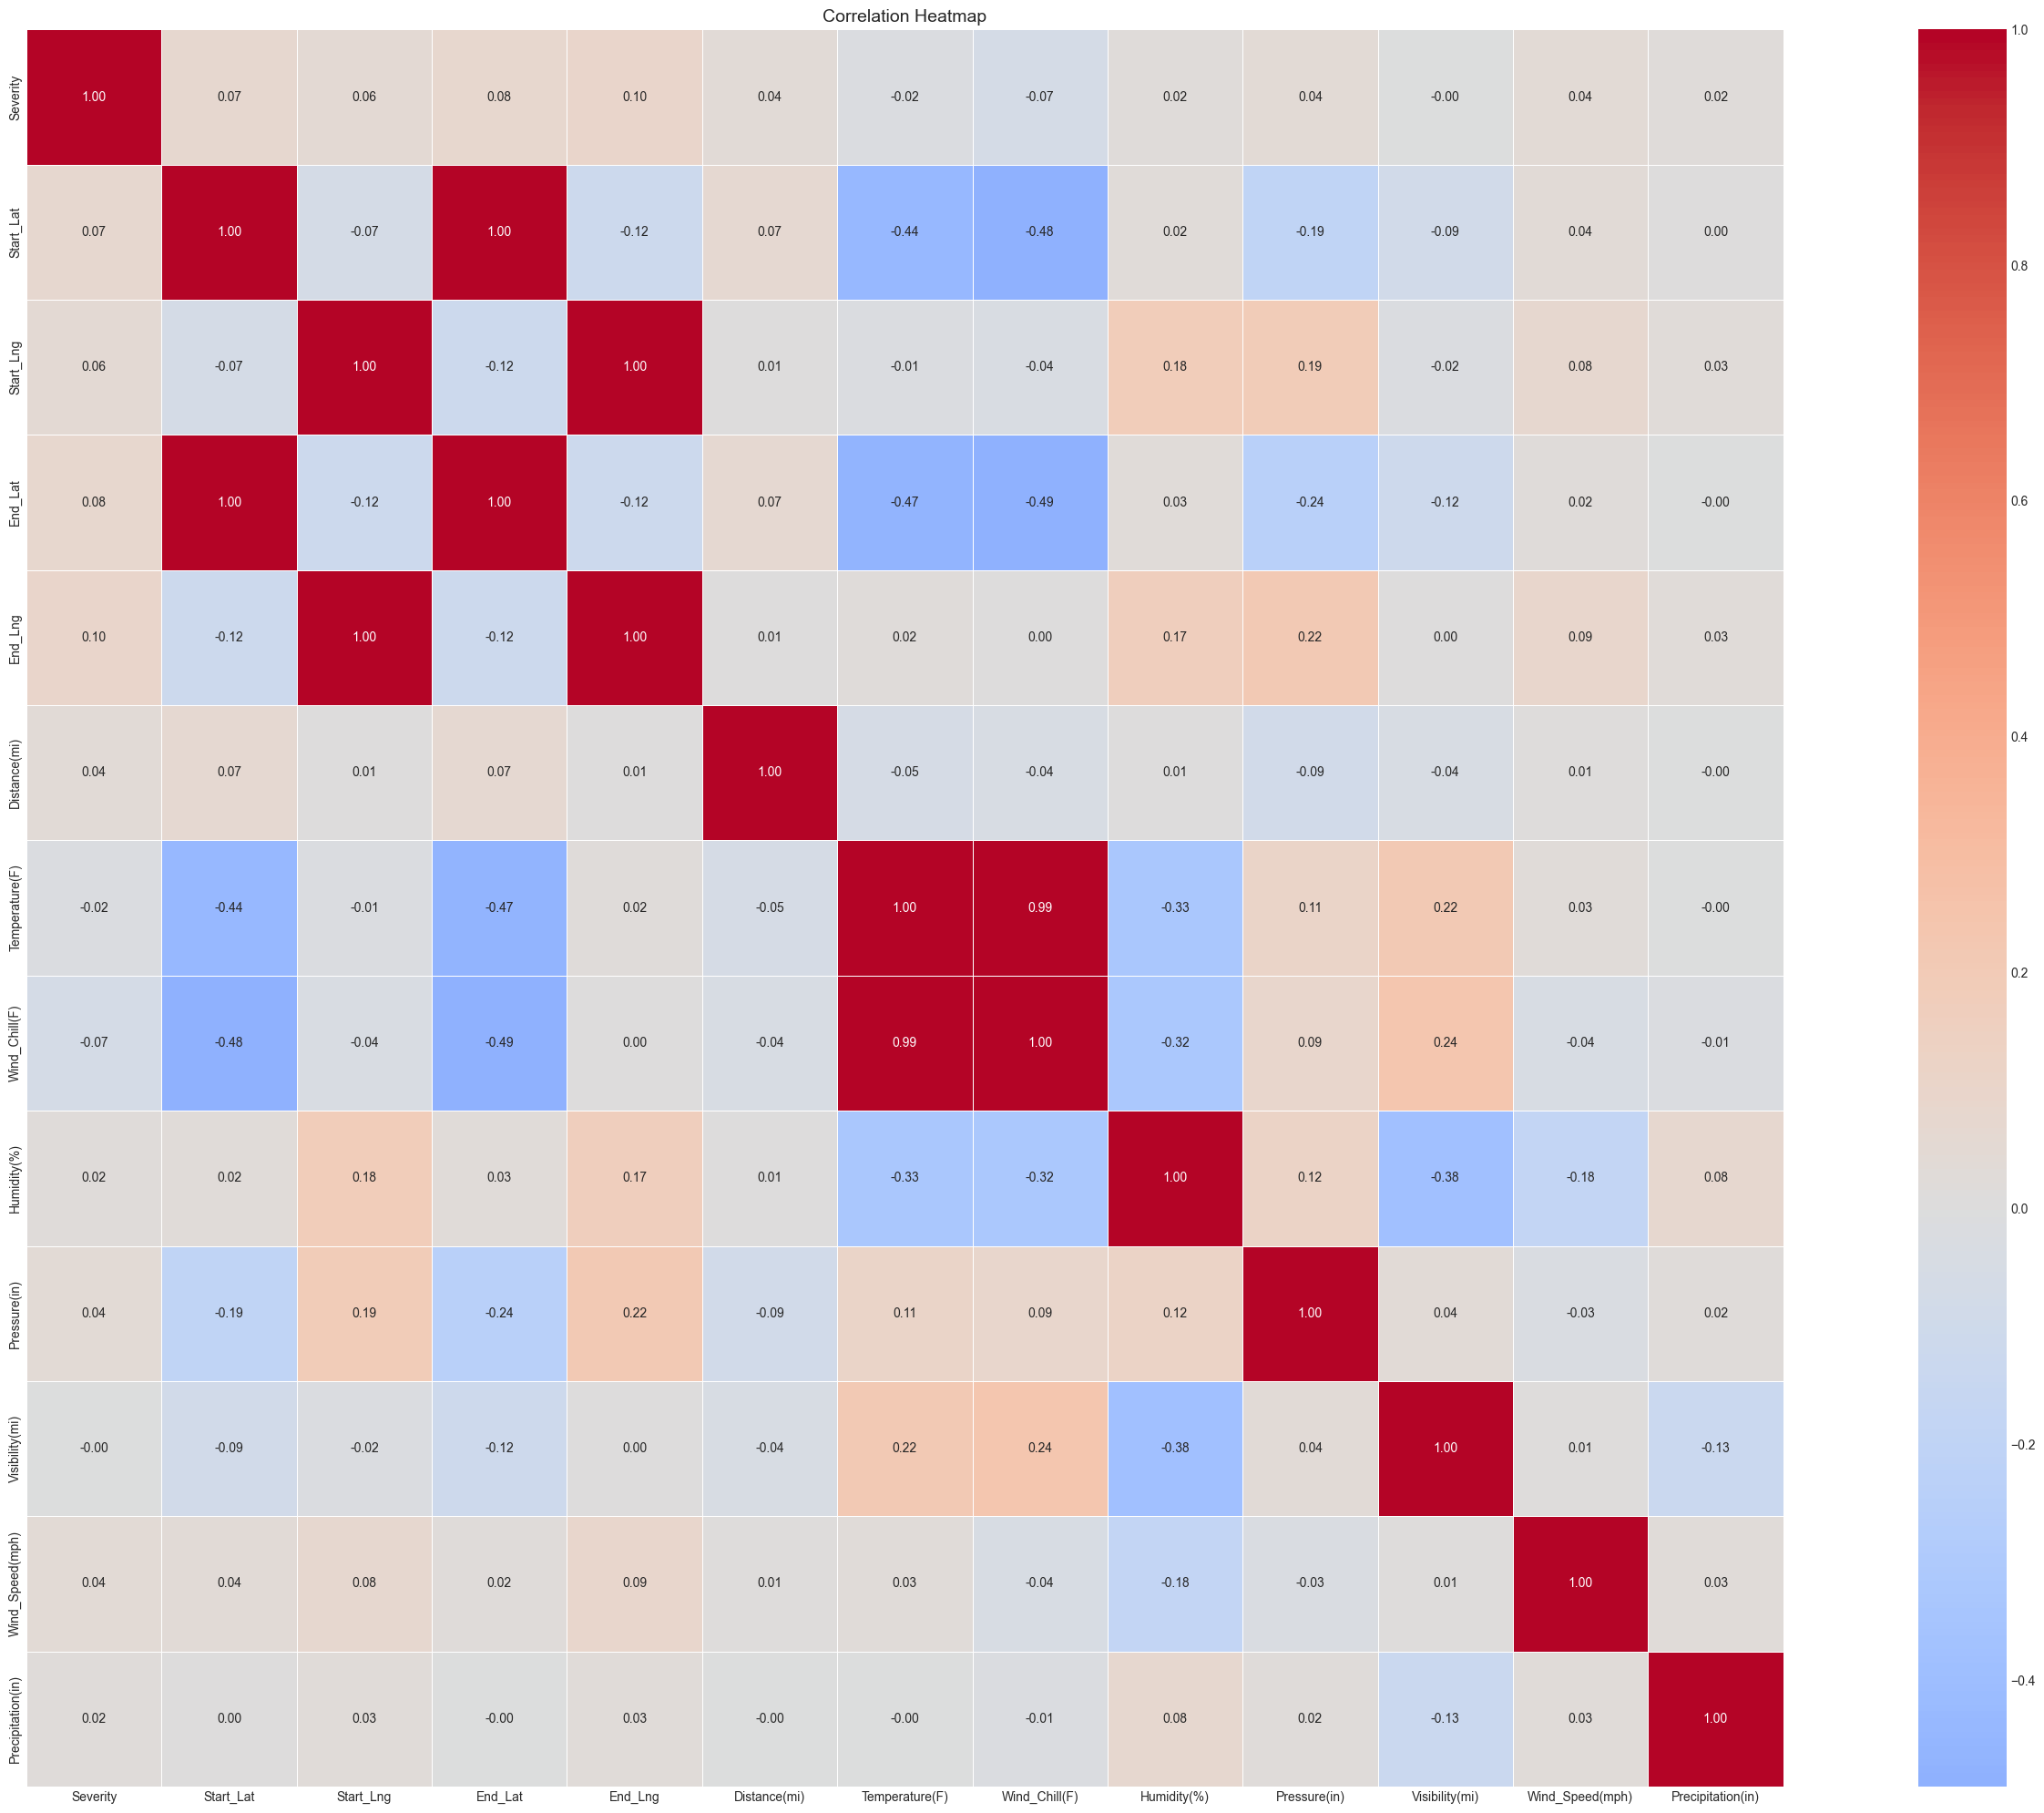

In [206]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(30, 20))

# Create the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Red = positive, Blue = negative
            center=0,             # Center the colormap at 0
            fmt='.2f',            # 2 decimal places
            square=True,          # Make cells square
            linewidths=0.5)       # Add grid lines

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

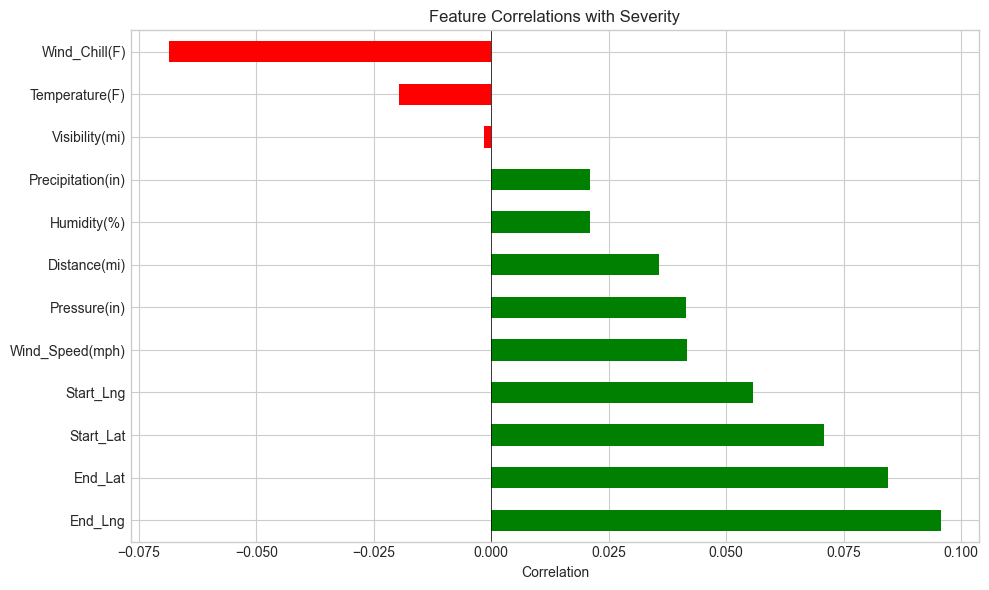

In [224]:
target_correlations = correlation_matrix[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

**What additional insights did you discover?**

Adding the NOAA weather data to our dataset provided additional context for understanding the environmental conditions during each flight. This allowed us to explore potential correlations between weather patterns and vessel performance, which could be valuable for predictive modeling. The null values in the NOAA data were minimal and did not significantly impact our analysis. Later we might consider removing rows with null values or imputing them if necessary.

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**
- Which features are most correlated with your target?
The features most correlated with the target (DurationMinutes) are primarily route-related variables such as EndBerthREF, StartLocationREF, StartBerthREF, and EndLocationREF. Among vessel characteristics, DraftNumeric shows the strongest relationship, indicating that vessel draft has some influence on transit duration.

- Which categorical features show the biggest differences in target?
The Direction variable shows the clearest separation in median duration across categories, making it one of the most influential categorical predictors. Route-related categorical features (berths and locations) also show meaningful differences.

- Are there any features that seem unimportant?
Some environmental variables display very low individual correlation with the target, suggesting limited standalone importance, although they may still contribute through interaction effects.

- Did you discover any interesting patterns or relationships?
There are clear patterns in the route-related features and the Direction variable, indicating that these factors play a significant role in the target variable.

- Are there any concerns about the data (outliers, skewness, etc.)?
Some plots show very large duration values (>1500 minutes), which could be considered outliers and may need to be addressed in the modeling process. Possible causes might be unusual operational delays.
In general data seems reasonably clean.

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [226]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

# YOUR CODE HERE:

df_clean = df.copy()

print(f"Starting shape: {df_clean.shape}")

Starting shape: (500000, 46)


In [209]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: ['ID', 'Humidity(%)']

3. High cardinality (>100 unique): ['Start_Time', 'End_Time']

4. Low variance (>95% same value): ['Country', 'Amenity', 'Bump', 'Give_Way', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Turning_Loop']


In [227]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
    'ID',
    'Description',
    #'Distance(mi)', # probably not needed for modeling, and has some missing values
    'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Airport_Code', # Location details may be redundant with lat/lng, and have some missing values
    'End_Lat', 'End_Lng', # These are highly correlated with Start_Lat and Start_Lng, and we filled missing values based on them, so we can drop them to avoid redundancy
    
    'Timezone',
]

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

Dropped 12 columns: ['ID', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Airport_Code', 'End_Lat', 'End_Lng', 'Timezone']
New shape: (500000, 34)


**Explain which columns you dropped and why:**

    'StartDate', 'CompletionDate', 'StartDateUTC' # These columns are likely not needed for modeling
    'Length', 'Draught', # DraftNumeric should be a good representation of the vessel size
    'AirDraftNumeric', # to many 0 values, consistence with missing information
    'MConcernREF', # High cardinality and may not be predictive
    'WL_CBBT_Chesapeake_Channel_VA_flag', 'WL_Windmill_Point_VA_flag', 'WL_Annapolis_MD_flag' # Similar values, likely redundant

### 5.2 Handle Duplicate Rows

In [228]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

# YOUR CODE HERE:
row_count_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
row_count_after = len(df_clean)
print(f"Removed {row_count_before - row_count_after} duplicate rows.")

Removed 530 duplicate rows.


### 5.3 Handle Missing Values

In [229]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
Precipitation(in)        142294
Wind_Chill(F)            129132
Wind_Speed(mph)           36874
Visibility(mi)            11462
Wind_Direction            11358
Humidity(%)               11350
Weather_Condition         11281
Temperature(F)            10679
Pressure(in)               9151
Weather_Timestamp          7824
Sunrise_Sunset             1560
Civil_Twilight             1560
Nautical_Twilight          1560
Astronomical_Twilight      1560
dtype: int64


In [230]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

# YOUR CODE HERE:
# % of missing values are very low, so I think we could remove rows with missing values without losing much data
df_clean_total_rows_before = len(df_clean)

df_clean = df_clean.dropna()

df_clean_total_rows_after = len(df_clean)

print(f"Removed {df_clean_total_rows_before - df_clean_total_rows_after} rows with missing values. New shape: {df_clean.shape}")

Removed 162134 rows with missing values. New shape: (337336, 34)


In [231]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

[Describe what you did for each column and why]

### 5.4 Handle Outliers (if needed)

In [232]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
Severity: 49,912 outliers (14.8%) | bounds: [2.00, 2.00]
Distance(mi): 37,846 outliers (11.2%) | bounds: [-0.95, 1.59]
Temperature(F): 1,780 outliers (0.5%) | bounds: [6.00, 118.00]
Wind_Chill(F): 4,161 outliers (1.2%) | bounds: [3.50, 119.50]
Pressure(in): 22,904 outliers (6.8%) | bounds: [28.02, 31.10]
Visibility(mi): 67,479 outliers (20.0%) | bounds: [10.00, 10.00]
Wind_Speed(mph): 7,329 outliers (2.2%) | bounds: [-7.50, 20.50]
Precipitation(in): 26,744 outliers (7.9%) | bounds: [0.00, 0.00]


In [ ]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:

# df_clean = df_clean[(df_clean['DurationMinutes'] < 1500) & (df_clean['DurationMinutes'] > 0)]
# print(df_clean.shape)

**Explain your outlier handling strategy (or why you kept them):**

As we discovered during our exploratory data analysis, there were some extreme outliers in the `DurationMinutes` column. To handle these outliers, we decided to remove rows where `DurationMinutes` exceeded 1500 minutes, as these values were not representative of typical durations and could skew our analysis.

### 5.5 Data Type Corrections

In [233]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump                        bool
Crossing                    bool
Give_Way                    bool
Junction                    bool
No_Exit                     bool
Railway                     bool
Roundabout                  bool
Station                     bool
Stop                        bool
Traffic_Calming             bool
Traffic_Signal              bool
Turning_Loop           

In [ ]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

# YOUR CODE HERE:
# df_clean['Propulsion'] = df_clean['Propulsion'].astype('category')
# df_clean['Direction'] = df_clean['Direction'].astype('category')


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [234]:

def dangerous_conditions_score(row):
    score = 0

    weather = str(row.get('Weather_Condition', '')).strip().lower()

    # Visibility
    visibility = row.get('Visibility(mi)')
    if pd.notna(visibility):
        if visibility < 1:
            score += 3
        elif visibility < 3:
            score += 2
        elif visibility < 5:
            score += 1

    # Precipitation amount
    precipitation = row.get('Precipitation(in)')
    if pd.notna(precipitation):
        if precipitation > 0.3:
            score += 2
        elif precipitation > 0:
            score += 1
    
    # Temperature / Wind Chill
    temp = row.get('Temperature(F)')
    wind_chill = row.get('Wind_Chill(F)')

    # Use wind chill if available (better for cold risk)
    effective_temp = wind_chill if pd.notna(wind_chill) else temp

    if pd.notna(effective_temp):
        if effective_temp < 32:
            score += 2   # freezing
        elif effective_temp > 100:
            score += 1   # extreme heat

    # Humidity
    humidity = row.get('Humidity(%)')
    if pd.notna(humidity) and humidity > 90:
        score += 1   # high humidity → fog potential
    
    # Pressure
    pressure = row.get('Pressure(in)')
    if pd.notna(pressure) and pressure < 29.5:
        score += 1   # storm indicator
        
    # Wind speed
    wind = row.get('Wind_Speed(mph)')
    if pd.notna(wind):
        if wind > 40:
            score += 2
        elif wind > 25:
            score += 1

    # Wind Direction (optional signal)
    wind_dir = str(row.get('Wind_Direction', '')).upper()

    # Gulf / coastal context → certain directions can be worse
    if wind_dir in ['N', 'NE', 'NW']:
        score += 0.5   # colder fronts / instability (small weight)

    # Darkness
    if row.get('Sunrise_Sunset') == 'Night':
        score += 1
    if row.get('Astronomical_Twilight') == 'Night':
        score += 1

    # Weather text categories
    severe_terms = [
        'tornado', 'thunderstorm', 't-storm', 'heavy t-storm',
        'heavy thunderstorms and rain', 'thunder in the vicinity',
        'hail', 'small hail', 'squalls', 'duststorm'
    ]

    winter_terms = [
        'heavy snow', 'snow and sleet', 'freezing rain',
        'light freezing rain', 'freezing drizzle',
        'heavy freezing drizzle', 'ice pellets',
        'light ice pellets', 'sleet', 'wintry mix',
        'blowing snow', 'drifting snow'
    ]

    low_visibility_terms = [
        'fog', 'mist', 'haze', 'smoke', 'blowing dust',
        'widespread dust', 'sand', 'dust whirl'
    ]

    moderate_terms = [
        'rain', 'drizzle', 'snow', 'showers', 'thunder'
    ]

    # Add points from text condition
    if any(term in weather for term in severe_terms):
        score += 3
    elif any(term in weather for term in winter_terms):
        score += 3
    elif any(term in weather for term in low_visibility_terms):
        score += 2
    elif any(term in weather for term in moderate_terms):
        score += 1

    # Windy modifier
    if 'windy' in weather:
        score += 1

    # Final label
    return score

In [235]:
df_clean['DangerousScore'] = df_clean.apply(dangerous_conditions_score, axis=1)

# remove the original weather condition columns to avoid data leakage
df_clean = df_clean.drop(columns=[
    'Temperature(F)', 
    'Wind_Chill(F)', 
    'Humidity(%)', 
    'Pressure(in)', 
    'Visibility(mi)', 
    'Wind_Direction', 
    'Wind_Speed(mph)', 
    'Precipitation(in)', 
    'Weather_Condition',
    
    'Weather_Timestamp',
    'Sunrise_Sunset',
    'Nautical_Twilight',
    'Civil_Twilight',
    'Astronomical_Twilight',
])

In [236]:

road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

existing = [f for f in road_features if f in df.columns]

# Total road features present
df_clean['n_road_features'] = df_clean[existing].sum(axis=1)

# Traffic control present
control_features = ['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming']
existing_control = [f for f in control_features if f in df_clean.columns]
df_clean['has_traffic_control'] = df_clean[existing_control].any(axis=1).astype(int)

# remove original road features
df_clean = df_clean.drop(columns=existing)
df_clean = df_clean.drop(columns=existing_control)


KeyError: "['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming'] not found in axis"

In [ ]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# YOUR CODE HERE:
# actual_trips = (
#     df_clean[['StartLocationREF','EndLocationREF','StartBerthREF','EndBerthREF']]
#     .drop_duplicates()
#     .reset_index(drop=True)
# )

# actual_trips['RouteIndex'] = actual_trips.index

# df_clean = df_clean.merge(
#     actual_trips,
#     on=['StartLocationREF','EndLocationREF','StartBerthREF','EndBerthREF'],
#     how='left'
# )

# # drop columns that are no longer needed
# columns_to_drop = ['StartLocationREF','EndLocationREF','StartBerthREF','EndBerthREF']
# df_clean = df_clean.drop(columns=columns_to_drop)

In [ ]:
# route_index_counts = df_clean['RouteIndex'].value_counts()

# print(route_index_counts.head(30))

# # show a bar chart of route_index_counts
# plt.figure(figsize=(12, 6))
# plt.bar(route_index_counts.index, route_index_counts.values)
# plt.xlabel('RouteIndex')
# plt.ylabel('Count')
# plt.title('Distribution of RouteIndex')
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

**Explain your new features:**

As a route is defined by its start and end locations and berths, we created a new feature called `RouteIndex` to uniquely identify each route. After analyzing the data, this idea seemed promising as it allows us to capture route-specific characteristics that could influence the duration of trips. It also helps us removing the route columns from the dataset, reducing redundancy and simplifying the data structure.

### 6.2 Encode Categorical Variables

In [237]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

# YOUR CODE HERE:
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique values: {df_clean[col].nunique()}")
    if df_clean[col].nunique() <= 10:
        print("Recommendation: one-hot encoding")
    else:
        print("Recommendation: consider label encoding or dropping")
    print()

cat_cols = categorical_cols

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df_clean[col].nunique()}")
    print(f"Top 10 value counts:\n{df_clean[col].value_counts().head(10)}")
    
    
    

Column: Source
Number of unique values: 3
Recommendation: one-hot encoding

Column: Start_Time
Number of unique values: 326915
Recommendation: consider label encoding or dropping

Column: End_Time
Number of unique values: 333005
Recommendation: consider label encoding or dropping


Column: Source
Number of unique values: 3
Top 10 value counts:
Source
source1    230067
source2    102747
source3      4522
Name: count, dtype: int64

Column: Start_Time
Number of unique values: 326915
Top 10 value counts:
Start_Time
2021-01-26 16:16:13    10
2021-11-21 18:37:51     9
2021-02-16 06:42:43     8
2021-01-26 16:17:33     7
2021-02-04 03:06:00     7
2021-11-09 13:10:00     7
2020-12-16 13:54:00     7
2021-05-03 06:29:42     7
2020-09-08 03:30:50     6
2021-02-03 15:50:00     5
Name: count, dtype: int64

Column: End_Time
Number of unique values: 333005
Top 10 value counts:
End_Time
2021-11-22 08:00:00    9
2020-02-07 00:00:00    6
2020-02-11 00:00:00    6
2020-02-14 00:00:00    5
2020-02-06 00:00:

In [240]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:

# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['VesselTypeREF_encoded'] = le.fit_transform(df_clean['VesselTypeREF'])
# df_clean['Propulsion_encoded'] = le.fit_transform(df_clean['Propulsion'])
# df_clean['Direction_encoded'] = le.fit_transform(df_clean['Direction'])

# remove original columns
df_clean = df_clean.drop(['Source', 'Start_Time', 'End_Time'], axis=1)

In [238]:
df_clean.head()

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),DangerousScore,n_road_features,has_traffic_control
0,source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,0.000,0.0,0,0
1,source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,0.000,3.0,0,0
2,source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,0.152,1.0,1,0
3,source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,0.869,1.0,0,0
4,source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,0.166,0.0,0,0


**Explain your encoding strategy:**

I decided to use LabelEncoder for the 'Propulsion', 'VesselTypeREF' and 'Direction' columns because they are categorical with a limited number of unique values.

### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

In [ ]:
# # YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# # Add as many cells as you need!


# # get top 5 trip indices
# top_5_trip_indices = df_clean['RouteIndex'].value_counts().nlargest(5).index
# df_sample = df_clean[df_clean['RouteIndex'].isin(top_5_trip_indices)]

# # precompute counts
# counts = df_sample['RouteIndex'].value_counts()

# plt.figure(figsize=(12, 6))
# ax = sns.boxplot(x='RouteIndex', y='DurationMinutes', data=df_sample)

# # update x-axis labels with counts
# new_labels = [
#     f"{tick.get_text()} (n={counts[int(tick.get_text())]})"
#     for tick in ax.get_xticklabels()
# ]
# ax.set_xticklabels(new_labels)

# plt.title('Top 5 RouteIndex by DurationMinutes')
# plt.tight_layout()
# plt.show()


In [ ]:
# # get all trips with trip index 1
# df_trip_1 = df_clean[df_clean['RouteIndex'] == 1]
# print(f"Shape of route index 1 data: {df_trip_1.shape}")

# # show bar plot of DurationMinutes for route index 1
# plt.figure(figsize=(10, 6))
# sns.histplot(df_trip_1['DurationMinutes'], bins=30, kde=True)
# plt.title('DurationMinutes Distribution for Route Index 1')
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(20, 6))

# # Scatter plot of all data points
# plt.scatter(df_clean['RouteIndex'], df_clean['DurationMinutes'], alpha=0.6, s=60)

# plt.xlabel('Route Index')
# plt.ylabel('Duration (Minutes)')
# plt.title('Duration vs Route Index')
# plt.legend()
# plt.show()

**Explain your additional feature engineering:**

We did not create any additional features. However, I added some visualizations to better understand the relationship between the route index and the duration of each route. Once again, route index appears to have a strong influence on the duration, which is consistent with our expectations.

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [241]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

# YOUR CODE HERE:
numerical_features = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove(TARGET)  # Exclude the target column

for col in numerical_features:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    print(f"{col}: min={min_val}, max={max_val}, range={max_val - min_val}")

Start_Lat: min=24.555269, max=48.993651, range=24.438382
Start_Lng: min=-124.49758500000002, max=-67.842169, range=56.65541600000002
Distance(mi): min=0.0, max=112.968, range=112.968
DangerousScore: min=0.0, max=13.0, range=13.0
n_road_features: min=0, max=6, range=6
has_traffic_control: min=0, max=1, range=1


### 6.5 Final Sanity Checks

In [242]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 337,336 rows, 7 columns
   (Started with 500,000 rows, 46 columns)

2. Missing values: 0

3. Duplicate rows: 22290

4. Target variable 'Severity':
   - Min: 1.00
   - Max: 4.00
   - Mean: 2.15

5. Data types:
   - Numerical: 7
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [243]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (337336, 7)

Columns (7):
['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'DangerousScore', 'n_road_features', 'has_traffic_control']

Data types:
Severity                 int64
Start_Lat              float64
Start_Lng              float64
Distance(mi)           float64
DangerousScore         float64
n_road_features          int64
has_traffic_control      int64
dtype: object


In [244]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**
- Columns dropped:
    'StartDate', 'CompletionDate', 'StartDateUTC', # These columns are likely not needed for modeling as they are timestamps
    'WL_CBBT_Chesapeake_Channel_VA_flag', 'WL_Windmill_Point_VA_flag', 'WL_Annapolis_MD_flag' # Had similar values, likely redundant
    'StartLocationREF','EndLocationREF','StartBerthREF','EndBerthREF' # we replaced with RouteIndex
    'Propulsion', 'Direction' # we encoded these as categorical variables

- None duplicate rows found.
- Handled missing values:
    We removed rows with missing values as the % of missing data was small
    Also removed rows where Length or Depth was 0, as these were likely erroneous.

- Outliers addressed:
    we decided to remove rows where `DurationMinutes` exceeded 1500 minutes, as these values were not representative of typical durations and could skew our analysis.

- Data types corrected:
    None 

- New features created

- New features created:
    - RouteIndex: A unique identifier for each route based on start and end locations.

- Categorical variables encoded
    We encoded the `Propulsion` and `Direction` columns as categorical variables.

We those changes have prepared the dataset for modeling by ensuring that it is clean, consistent, and contains relevant features.


**Final feature list for modeling:**

[List all the features you'll use in your models]

VesselTypeREF
Length
Depth
Draught
DraftNumeric
AirDraftNumeric
MConcernREF
DurationMinutes
WL_CBBT_Chesapeake_Channel_VA
WL_CBBT_Chesapeake_Channel_VA_speed
WL_Windmill_Point_VA
WL_Windmill_Point_VA_speed
WL_Annapolis_MD
WL_Annapolis_MD_speed
CUR_Rappahannock_Shoal_Channel_speed
CUR_Rappahannock_Shoal_Channel_direction
CUR_York_Spit_LB_22_speed
CUR_York_Spit_LB_22_direction
CUR_Chesapeake_City_speed
CUR_Chesapeake_City_direction
RouteIndex
Propulsion_encoded
Direction_encoded

---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---